# ADANIPORTS Time Series Analysis
This project provides a comprehensive analysis of the historical price data for Adani Ports and Special Economic Zone Limited (APSEZ).

This notebook analyze the stock by examining its long-term trends, repeating seasonal patterns, and price volatility.

## Step 1: Environment Setup & Data Loading
It's begin by importing "analyzer" package modules and loading the raw CSV data.

The dataset includes daily Open, High, Low, and Close prices, which are the standard building blocks for financial modeling.

In [14]:
# Import the package modules
from analyzer.preprocessor import DataPreprocessor
from analyzer.analyzer import TimeSeriesAnalyzer
from analyzer.visualizer import TimeSeriesVisualizer
import pandas as pd

# Load the data
df = pd.read_csv("../data/ADANIPORTS.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


## Step 2: Preprocessing for Time Series Data.
This step reindexes, and handles outliers for the ADANIPORTS dataset.

### clean_headers() :  
        Removes leading/trailing spaces from column names.
### process_data() : 
        Converts dates, reindexes to daily frequency, and fills gaps.
### handle_outliers() : 
        Detects outliers using the IQR method and replaces them with the median.


In [18]:
 # --- STEP 2: PREPROCESSING ---
print("\n[Step 2] Preprocessing: Cleaning and Handling missed...")
# Ensure the 'Date' column is index for time-based operations
preprocessor = DataPreprocessor(df)
    
    # Chaining the processing steps for a cleaner flow
df_clean = preprocessor.clean_headers()
df_clean = preprocessor.process_data()
df_clean = preprocessor.handle_outliers()
print("[*] Data cleaned and outliers addressed.")


[Step 2] Preprocessing: Cleaning and Handling missed...
[*] Data cleaned and outliers addressed.


## STEP 3: Statisctical Analysis 
This part provides statistical tests (ADF, KPSS) and signal decomposition specifically tuned for financial datasets like ADANIPORTS.
### adf_test(): 
        Augmented Dickey-Fuller test for Stationarity. If p-value < 0.05, the data is stationary.
### kpss_test():   
        KPSS test (opposite of ADF). If p-value > 0.05, the data is stationary.
### decompose_signal(): 
        Splits data into Trend, Seasonal, and Residuals. Uses an additive model suitable for price data.
### get_volatility_stats():
        Calculates daily and annual volatility using percentage changes. 
        Annualized volatility = daily_std * sqrt(252 -trading days).
### daily_returns():
        Calculates daily returns from a price series


### The Importance of Stationarity
Most forecasting models (like ARIMA) require the data to be Stationary. Its mean and variance don't change over time. If a stock is trending up, it is non-stationary. 

In [19]:
# --- STEP 3: STATISTICAL ANALYSIS ---
print("\n[Step 3] Analysis: Extracting Statistical Insights...")
analyzer = TimeSeriesAnalyzer(df_clean)


[Step 3] Analysis: Extracting Statistical Insights...


#### 1. Augmented Dickey-Fuller (ADF) Test

This test checks for a "unit root" (a trend).

    Null Hypothesis (H0): The data is non-stationary.

    If the p-value is < 0.05, we reject H0 and conclude the data is stationary.

In [20]:
# Run Stationarity Test( ADF Test)
adf_res = analyzer.adf_test()
status = "STATIONARY" if adf_res['is_stationary'] else "NON-STATIONARY"
print(f"[*] ADF Test: {status} (p-value: {adf_res['p-value']:.4f})")
    

[*] ADF Test: NON-STATIONARY (p-value: 0.1177)


#### 2. KPSS Test
This is the against to the ADF test.

    Null Hypothesis (H0): The data is stationary.

    If the p-value is > 0.05, we fail to reject H0, confirming stationarity.

In financial data, it is common for ADF and KPSS to yield different results.

In [21]:
# Run KPSS Test
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
# This line hides the address and the explanation warning
warnings.filterwarnings("ignore", category=InterpolationWarning)
kpss_res = analyzer.kpss_test()
status = "STATIONARY" if kpss_res['is_stationary'] else "NON-STATIONARY"
print(f"[*] KPSS Test: {status} (p-value: {kpss_res['p-value']:.4f})")

[*] KPSS Test: NON-STATIONARY (p-value: 0.0100)


#### Volatility 
It refers to the degree of variation in the ADANIPORTS stock price over time. It is the most common way to measure Investment Risk.
If a stock's price stays relatively flat or moves in a predictable, slow line, it has low volatility. If the price swings wildly up and down in short periods, it has high volatility.
    Annualized Volatility
     Investors usually want to know the risk for a whole year, not just one day. 
     Since there are roughly 252 trading days in a year, the scale of the daily number is the "Square Root of Time" rule:$$\text{Annual Volatility} = \text{Daily Volatility} \times \sqrt{252}$$

In [22]:
# Calculate Volatility
vol = analyzer.get_volatility_stats()
print(f"[*] Annualized Volatility: {vol['Annual Volatility']:.2%}")


[*] Annualized Volatility: 99.25%


## Step 4: Visualize Time Series Analysis.
### plot_data(): 
        Plot Timeseries data
### plot_seasonal_heatmap():
        Creates a heatmap showing average price by Month and Year.
### plot_pacf_acf():
        Plots Autocorrelation and Partial Autocorrelation.
### plot_rolling_stats(,window=30):
        Plots original data vs a rolling mean for trend smoothing. 
### plot_decomposition():
        Plots the 4 components: Observed, Trend, Seasonal, and Residual.
### plot_daily_returns_distribution():
        Plot distribution of daily returns.


A Time Series Plot is essentially the "story" of a variable over time.

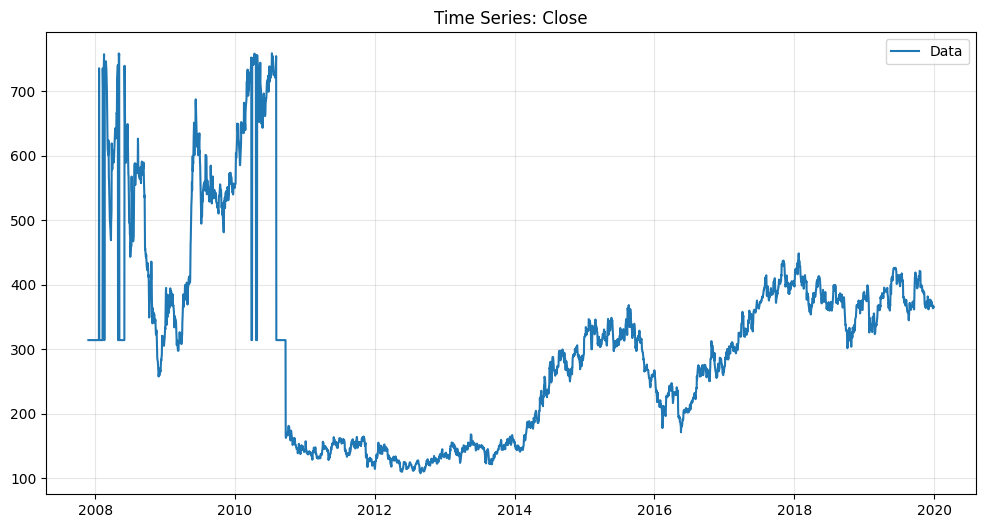

In [29]:
#  Visualize Data
viz = TimeSeriesVisualizer(df_clean)
viz.plot_data() 

### Decomposition
In time series analysis, a single dataset (like the ADANIPORTS stock price) is actually a combination of four distinct patterns or "components."
Breaking a series down into these parts is called Decomposition.

Understanding these components helps to filter out the "noise" and see the true underlying behavior of the data.
#### 1. Trend:
     The trend is the long-term direction of the data. It tells you if the series is generally increasing, decreasing, or staying flat over several years.
#### 2. Seasonality:
    Seasonality refers to patterns that repeat at fixed, regular intervals (e.g., daily, weekly, or yearly).
#### 3. Cyclical:
    Cyclical patterns are fluctuations that happen over a long period (usually 2–10 years) but do not have a fixed frequency. Seasonality is predictable ; cycles are unpredictable.
#### 4. Irregular / Noise:
    This is the "Residual" or the "Chaos." It represents random, one-time events that cannot be predicted by the model.

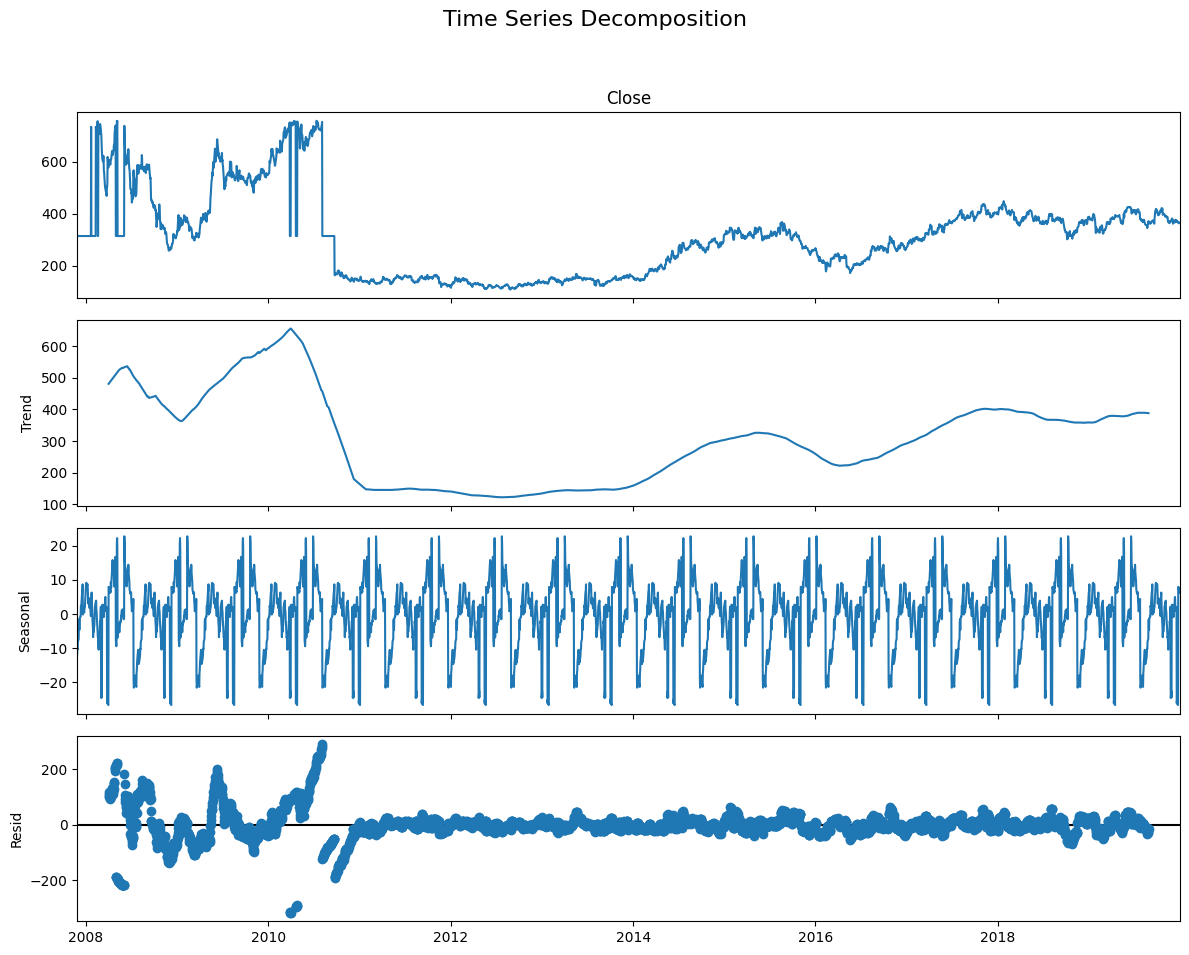

In [30]:
decomposition_results = analyzer.decompose_signal()
viz.plot_decomposition(decomposition_results)

#### Seasonal Heatmap
A heatmap uses color to represent the value of the stock. In time series, we usually set the Years on one axis and the Months on the other.
It highlights clusters of performance. For example, if the cells for "January" are consistently dark blue across 5 different years, it tells you that ADANIPORTS historically performs very well at the start of the year.

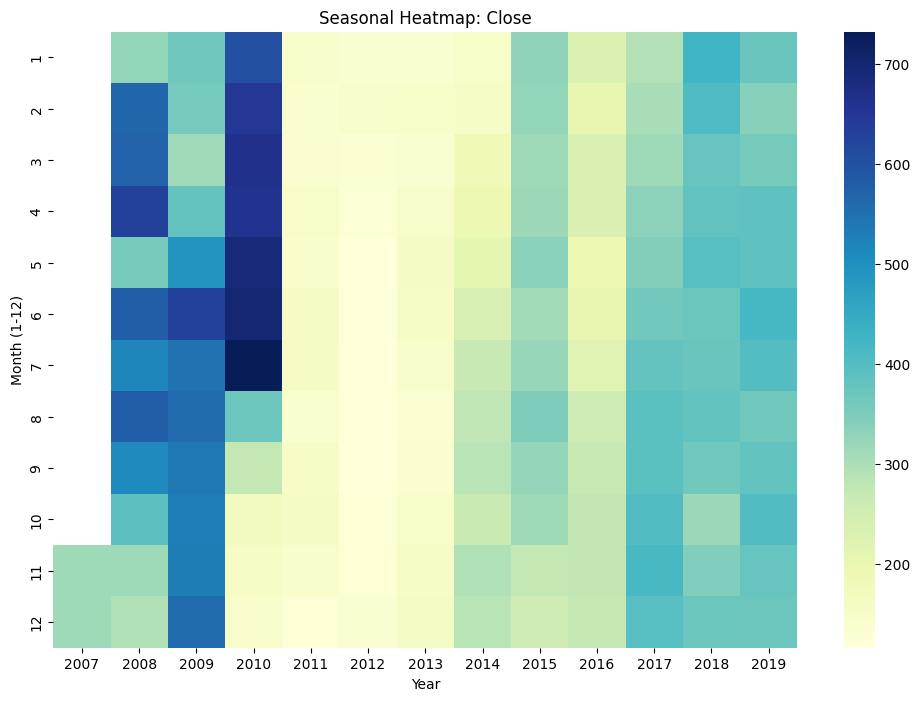

In [31]:
viz.plot_seasonal_heatmap()

### Autocorrelation
In time series analysis, ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) are the two most important tools for understanding how a stock price is related to its own past.
#### 1. ACF (Autocorrelation Function)
The ACF measures the correlation between a time series and a lagged version of itself.
#### 2. PACF (Partial Autocorrelation Function)
The PACF measures the correlation between the current price and a specific lag, removing the influence of all shorter lags.

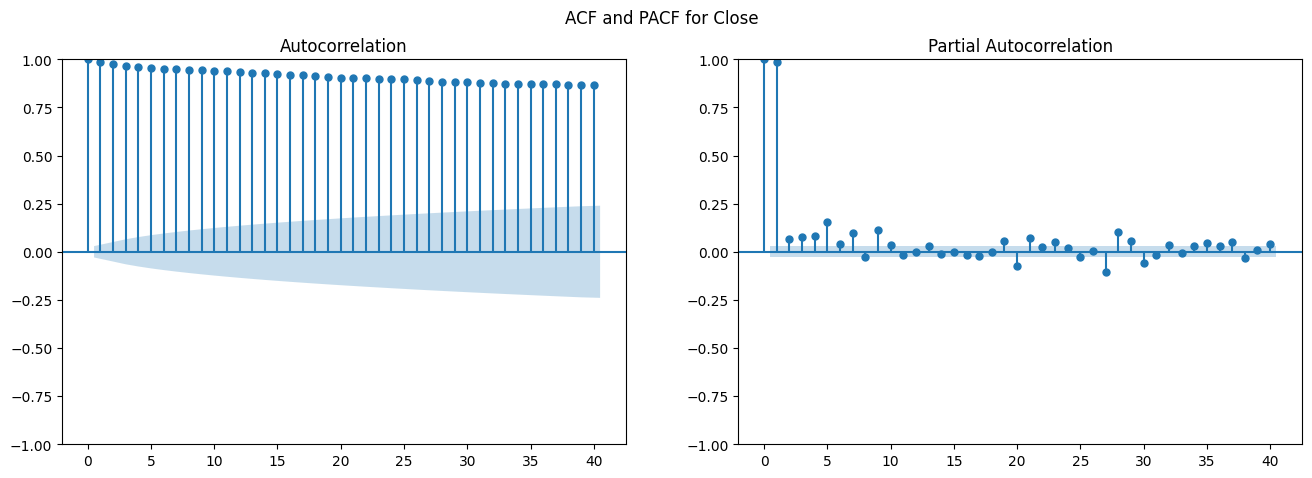

In [32]:
viz.plot_pacf_acf()

### Daily Returns Distribution
The Daily Returns Distribution plot (the histogram with the bell-shaped line) is designed to show the "Statistical Personality" and Risk Profile of the ADANIPORTS stock.

While a price chart shows you the journey, this plot shows you the probability of daily surprises.
Most financial models assume that stock returns follow a 'Normal Distribution'. However, real-world stocks often show 'Kurtosis' meaning they have fatter tails.

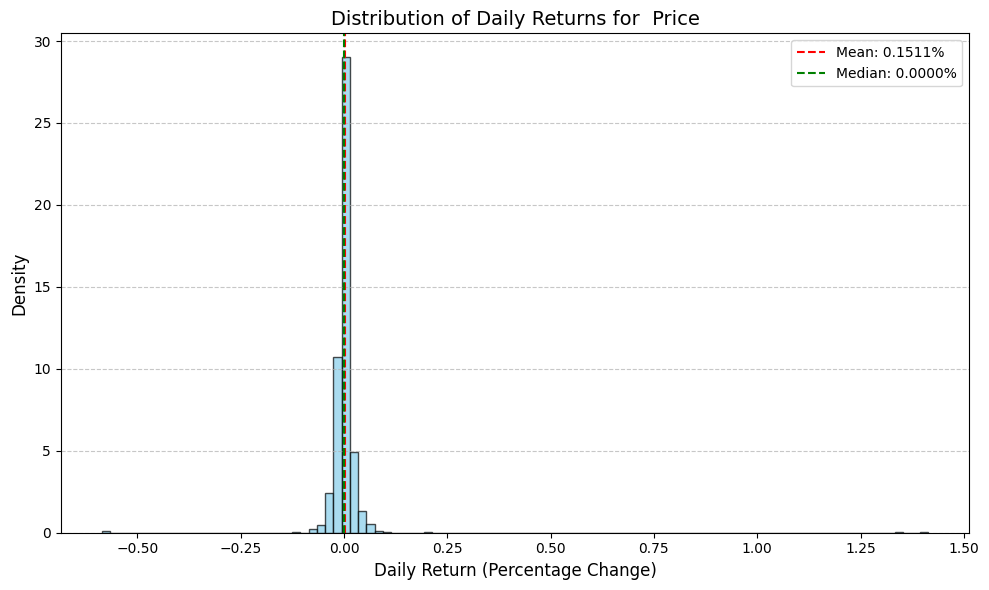

In [33]:
daily_ret = analyzer.daily_returns()
viz.plot_daily_returns_distribution(daily_ret)

### Moving average
The Moving Average is a statistical tool used to smooth out the daily "noise" of the stock market so you can see the true Trend.


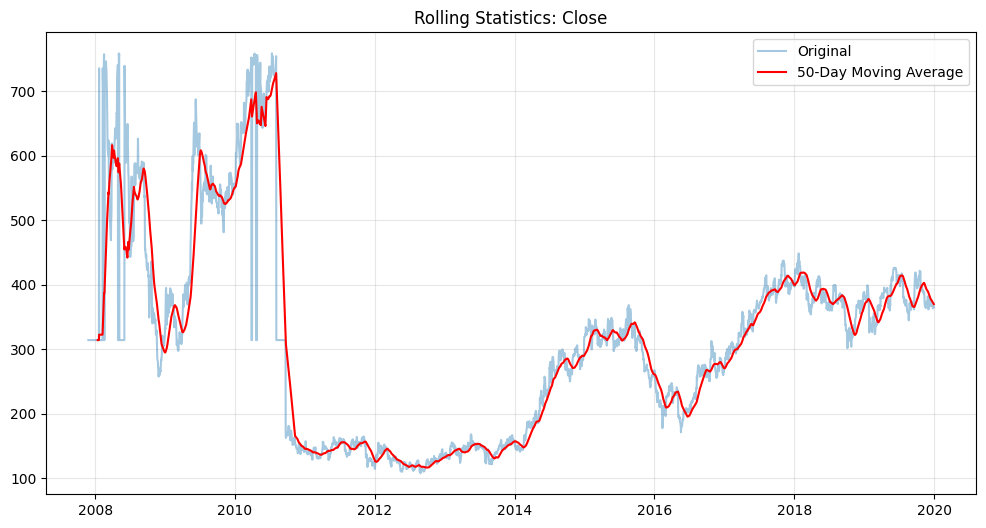

In [34]:
viz.plot_rolling_stats(window=50) # 50-day moving average

**References:**
+ https://pandas.pydata.org/docs/user_guide/index.html
+ https://seaborn.pydata.org/
+ https://matplotlib.org/
+ https://numpy.org/doc/
+ https://www.statsmodels.org/stable/user-guide.html
+ https://www.statsmodels.org/stable/tsa.html
